# Grocery Habit

My grocery habit in 2025.

## Import packages

In [1]:
import pandas as pd
import numpy as np 
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline
from scipy import stats
from datetime import datetime
from sklearn import preprocessing
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
import re

## Load dataset

In [2]:
# Creating the table in dataframe from a csv file
df_dirty = pd.read_csv(r"C:\Users\Clair\Documents\Code Development\Python Local\personal_finance\Grocery Habit.csv")

In [3]:
df_dirty

,Date,Month,Store,Money Spent
0,3/13/2023,3,Aldi,10.25
1,3/17/2023,3,Aldi,24.62
2,3/24/2023,3,Aldi,26.42
3,4/3/2023,4,Aldi,23.25
4,5/5/2023,5,Aldi,15.40
...,...,...,...,...
229,3/16/2025,3,Walmart,49.93
230,3/19/2025,3,Walmart,34.63
231,7/14/2025,7,Walmart,10.58
232,7/25/2025,7,Walmart,98.82


In [4]:
df_dirty.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 234 entries, 0 to 233
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Date         234 non-null    object 
 1   Month        234 non-null    int64  
 2   Store        234 non-null    object 
 3   Money Spent  234 non-null    float64
dtypes: float64(1), int64(1), object(2)
memory usage: 7.4+ KB


In [5]:
# convert the date column to date (it's already formatted as short date in csv)
import pandas as pd

# Convert "Date" column to datetime format
df_dirty["Date"] = pd.to_datetime(df_dirty["Date"])

# Check the data types after conversion
print(df_dirty.dtypes)

# Preview the DataFrame to verify the conversion
print(df_dirty.head())


Date           datetime64[ns]
Month                   int64
Store                  object
Money Spent           float64
dtype: object
        Date  Month Store  Money Spent
0 2023-03-13      3  Aldi        10.25
1 2023-03-17      3  Aldi        24.62
2 2023-03-24      3  Aldi        26.42
3 2023-04-03      4  Aldi        23.25
4 2023-05-05      5  Aldi        15.40


In [6]:
# df = df_dirty.copy()
# # extract year from Date column using regular expressions  
# df["Year"] = df["Date"].apply(lambda x: re.search(r"\d{4}", x).group())  
# df_2025 = df[df["Year"] == "2023"]  

df = df_dirty.copy()

# Convert "Date" column to datetime format
#df["Date"] = pd.to_datetime(df["Date"])

# Extract year from datetime column
df["Year"] = df["Date"].dt.year

# Filter data for the year 2023
df_2025 = df[df["Year"] == 2025]

print(df_2025.head())


         Date  Month                     Store  Money Spent  Year
37 2025-08-07      8                      Aldi         9.28  2025
38 2025-02-16      2  Asia Pacific Supermarket        32.88  2025
39 2025-07-12      7  Asia Pacific Supermarket        36.13  2025
40 2025-07-12      7  Asia Pacific Supermarket        41.46  2025
41 2025-07-19      7  Asia Pacific Supermarket        18.15  2025


<Axes: >

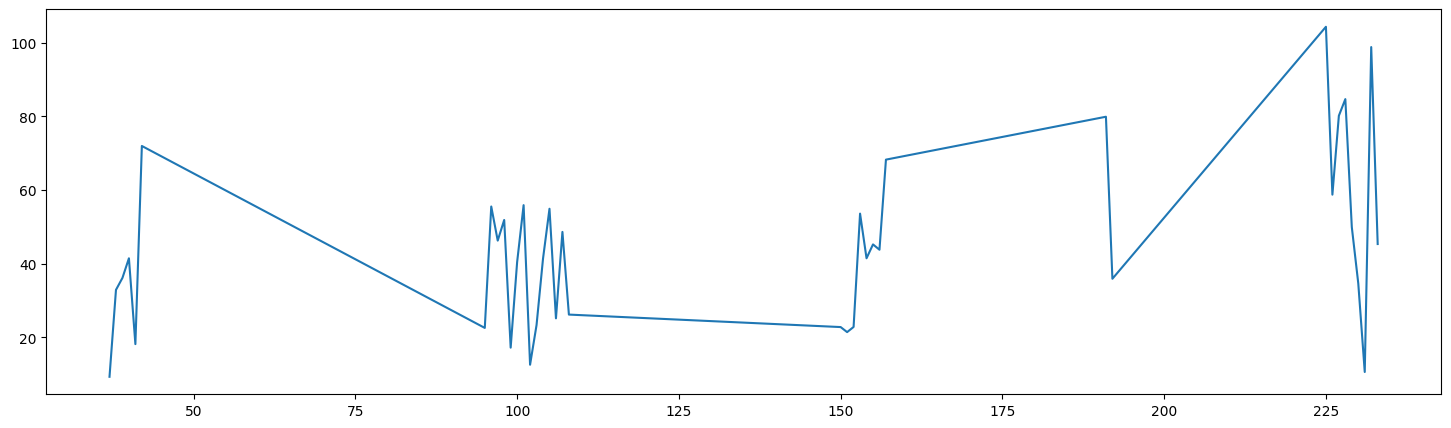

In [7]:
# Big picture - identifying pattern with money spending
df_2025['Money Spent'].plot(figsize = (18,5))

In [8]:
# Checking for null values
df_2025.isnull().values.any()

False

## Clean/modify data

In [9]:
# Converting the date object mm/dd/yyyy to another date object mm-dd-yyyy
df_2025["Date"] = pd.to_datetime(df_2025["Date"]).dt.date
print(df_2025.dtypes,'\n')

# Previewing the table - just checking the Date columns is properly converted
print(df_2025.head(2))

Date            object
Month            int64
Store           object
Money Spent    float64
Year             int32
dtype: object 

          Date  Month                     Store  Money Spent  Year
37  2025-08-07      8                      Aldi         9.28  2025
38  2025-02-16      2  Asia Pacific Supermarket        32.88  2025


C:\Users\Clair\AppData\Local\Temp\ipykernel_16004\377907037.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2025["Date"] = pd.to_datetime(df_2025["Date"]).dt.date


### High level

In [10]:
# Extremes
Cheap = df_2025['Money Spent'].min()
Expensive = df_2025['Money Spent'].max()
Paid = df_2025['Money Spent'].sum().round(2)

print(f'Most cheap trip:\n $',Cheap,'\n')
print(f'Most expensive trip:\n $',Expensive,'\n')
print(f'Amount spent toward feeding myself thus far:\n $',Paid,'\n')

Most cheap trip:
 $ 9.28 

Most expensive trip:
 $ 104.33 

Amount spent toward feeding myself thus far:
 $ 1733.99 



In [11]:
# Basic stats by store
print('The amount of money I spend at each of the main stores:')
Store_group = df_2025.groupby(['Store']).agg({'Money Spent': ['min', 'max', 'mean', 'median']}).round(2)
Store_group.columns = ['min', 'max', 'mean', 'median']
Store_group.reset_index()
Store_group

The amount of money I spend at each of the main stores:


,min,max,mean,median
Store,,,,
Aldi,9.28,9.28,9.28,9.28
Asia Pacific Supermarket,18.15,71.96,40.12,36.13
Food City,12.55,55.89,37.27,40.89
Local Asian Market,21.41,68.25,39.91,42.62
Publix,35.90,79.90,57.90,57.90
Walmart,10.58,104.33,63.02,58.74


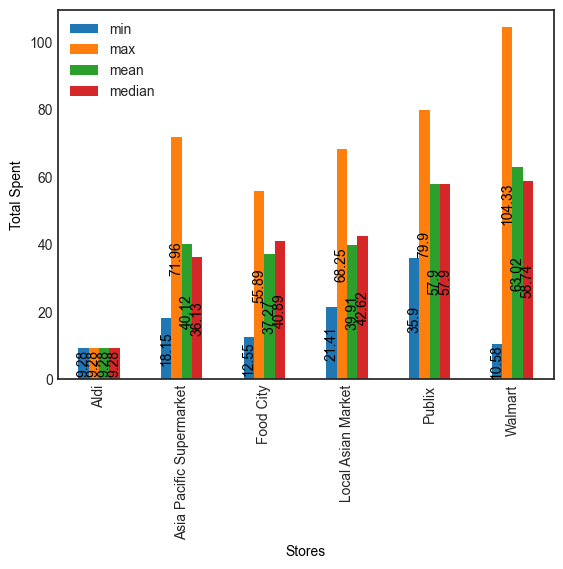

In [12]:
# Stats grouped by store viz
matplotlib.style.use('seaborn-v0_8-white') 
ax = Store_group.plot.bar()
for container in ax.containers:
    ax.bar_label(container, label_type = 'center', rotation = 'vertical', color = 'black', fontsize = 10)

plt.xlabel('Stores', size = 10, color = 'black')
plt.ylabel('Total Spent', size = 10, color = 'black')


plt.show()

In [13]:
# Count of trips by store in the last x months
Trip_count = df_2025['Store'].value_counts()
print(Trip_count)

Store
Food City                   14
Walmart                      9
Local Asian Market           8
Asia Pacific Supermarket     5
Publix                       2
Aldi                         1
Name: count, dtype: int64


<Axes: ylabel='count'>

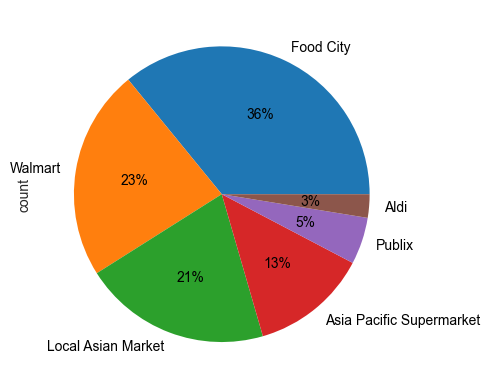

In [14]:
Trip_count.plot(kind = 'pie', y = 'Store', autopct = '%1.0f%%', textprops = {'color':'black'})

### Total

#### Monthly

In [15]:
# Spending per month
Monthly_split_total = df_2025.groupby('Month')['Money Spent'].sum()
Monthly_split_total

Month
1    185.62
2    259.02
3    243.93
6    208.57
7    454.47
8    203.44
9    178.94
Name: Money Spent, dtype: float64

In [16]:
# Spending per month avg
Monthly_split_avg = df_2025.groupby('Month')['Money Spent'].median()
Monthly_split_avg

Month
1    58.74
2    39.57
3    49.93
6    41.46
7    41.35
8    43.78
9    42.26
Name: Money Spent, dtype: float64

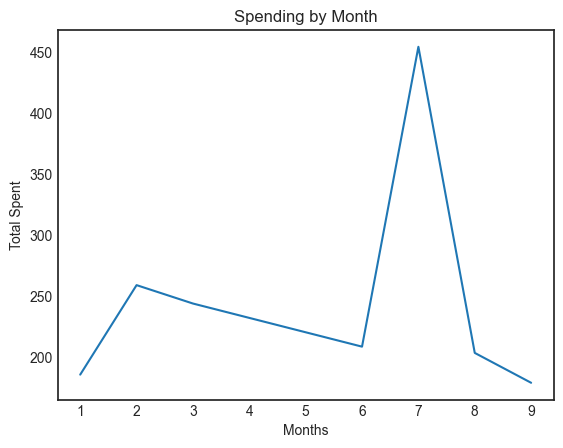

In [17]:
Monthly_split_total.plot(kind = 'line')

plt.title('Spending by Month')
plt.xlabel('Months')
plt.ylabel('Total Spent')

plt.show()

#### Store

In [18]:
# Total Spending by store
Store_split = df_2025.groupby('Store')['Money Spent'].sum()
Store_split

Store
Aldi                          9.28
Asia Pacific Supermarket    200.58
Food City                   521.80
Local Asian Market          319.31
Publix                      115.80
Walmart                     567.22
Name: Money Spent, dtype: float64

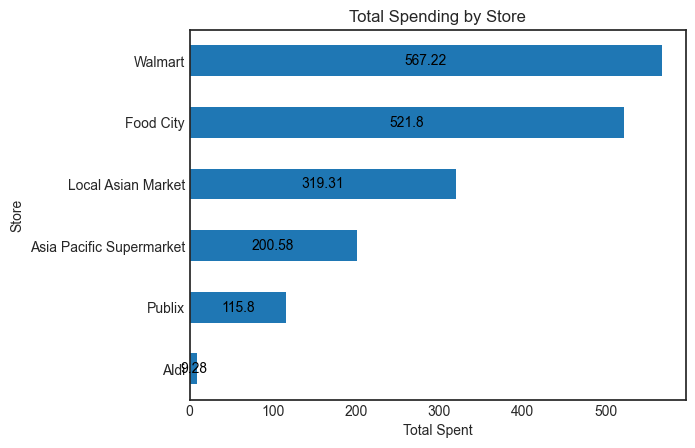

In [19]:
# sort the values in desc order so the barh will be most to least
Store_split = Store_split.sort_values(ascending=True) 
ax = Store_split.plot.barh()
for container in ax.containers:
    ax.bar_label(container, label_type = 'center', color = 'black', fontsize = 10)
    

plt.title('Total Spending by Store')
plt.xlabel('Total Spent')
plt.ylabel('Store')

plt.show()